In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Road Accident Data.csv")
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


1. Accident severity count

In [4]:
df["Accident_severity"].value_counts()

,count
Accident_severity,
Slight Injury,10415
Serious Injury,1743
Fatal injury,158


2. Accidents by day

In [5]:
df["Day_of_week"].value_counts()

,count
Day_of_week,
Friday,2041
Thursday,1851
Wednesday,1840
Tuesday,1770
Monday,1681
Saturday,1666
Sunday,1467


3. Weather conditions

In [6]:
df["Weather_conditions"].value_counts()

,count
Weather_conditions,
Normal,10063
Raining,1331
Other,296
Unknown,292
Cloudy,125
Windy,98
Snow,61
Raining and Windy,40
Fog or mist,10


4. Light conditions

In [7]:
df["Light_conditions"].value_counts()

,count
Light_conditions,
Daylight,8798
Darkness - lights lit,3286
Darkness - no lighting,192
Darkness - lights unlit,40


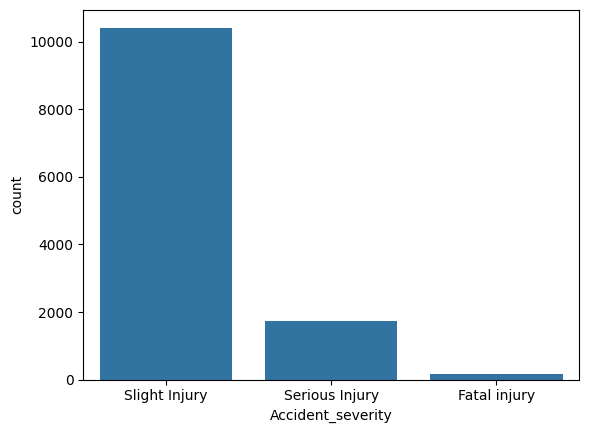

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data = df, x = "Accident_severity")
plt.show()

Compare severity vs conditions

In [9]:
pd.crosstab(df["Weather_conditions"], df["Accident_severity"])

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Weather_conditions,,,
Cloudy,0,8,117
Fog or mist,0,1,9
Normal,135,1474,8454
Other,0,28,268
Raining,23,158,1150
Raining and Windy,0,2,38
Snow,0,5,56
Unknown,0,51,241
Windy,0,16,82


In [10]:
pd.crosstab(df["Light_conditions"], df["Accident_severity"])

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Light_conditions,,,
Darkness - lights lit,66,465,2755
Darkness - lights unlit,0,7,33
Darkness - no lighting,5,49,138
Daylight,87,1222,7489


Convert to percentage

In [11]:
weather_ct = pd.crosstab(df["Weather_conditions"], df["Accident_severity"],
                         normalize = 'index') * 100
weather_ct

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Weather_conditions,,,
Cloudy,0.000000,6.400000,93.600000
Fog or mist,0.000000,10.000000,90.000000
Normal,1.341548,14.647719,84.010732
Other,0.000000,9.459459,90.540541
Raining,1.728024,11.870774,86.401202
Raining and Windy,0.000000,5.000000,95.000000
Snow,0.000000,8.196721,91.803279
Unknown,0.000000,17.465753,82.534247
Windy,0.000000,16.326531,83.673469


In [12]:
light_ct = pd.crosstab(df["Light_conditions"], df["Accident_severity"],
                       normalize = 'index') * 100
light_ct

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Light_conditions,,,
Darkness - lights lit,2.008521,14.150943,83.840536
Darkness - lights unlit,0.000000,17.500000,82.500000
Darkness - no lighting,2.604167,25.520833,71.875000
Daylight,0.988861,13.889520,85.121619


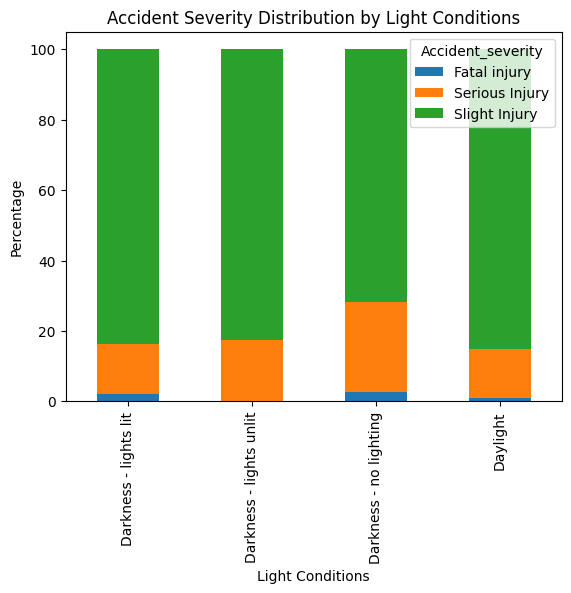

In [13]:
light_ct.plot(kind = "bar", stacked = True)
plt.title("Accident Severity Distribution by Light Conditions")
plt.xlabel("Light Conditions")
plt.ylabel("Percentage")
plt.show()

In [14]:
pd.crosstab(df["Age_band_of_driver"], df["Accident_severity"],
            normalize = 'index') * 100

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Age_band_of_driver,,,
18-30,1.451651,14.141887,84.406462
31-50,1.321263,13.237093,85.441644
Over 51,1.514196,16.214511,82.271293
Under 18,1.454545,20.484848,78.060606
Unknown,0.387597,11.111111,88.501292


In [15]:
pd.crosstab(df["Driving_experience"], df["Accident_severity"],
            normalize = 'index') * 100

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Driving_experience,,,
1-2yr,1.195900,12.984055,85.820046
2-5yr,1.760429,14.580941,83.658630
5-10yr,1.219150,13.737734,85.043116
Above 10yr,1.282051,14.279399,84.438550
Below 1yr,0.521610,15.424739,84.053651
No Licence,0.000000,11.016949,88.983051
unknown,3.030303,18.181818,78.787879


In [22]:
pd.crosstab(df["Type_of_vehicle"], df["Accident_severity"],
            normalize = 'index') * 100

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Type_of_vehicle,,,
Automobile,1.248050,14.726989,84.024961
Bajaj,0.000000,10.344828,89.655172
Bicycle,0.000000,4.761905,95.238095
Long lorry,1.044386,17.493473,81.462141
Lorry (11?40Q),1.293900,18.299445,80.406654
Lorry (41?100Q),1.189387,12.808783,86.001830
Motorcycle,1.694915,16.384181,81.920904
Other,1.324503,11.423841,87.251656
Pick up upto 10Q,1.849568,16.276202,81.874229


Accident Severity Distribution (Most accidents are slight injuries)

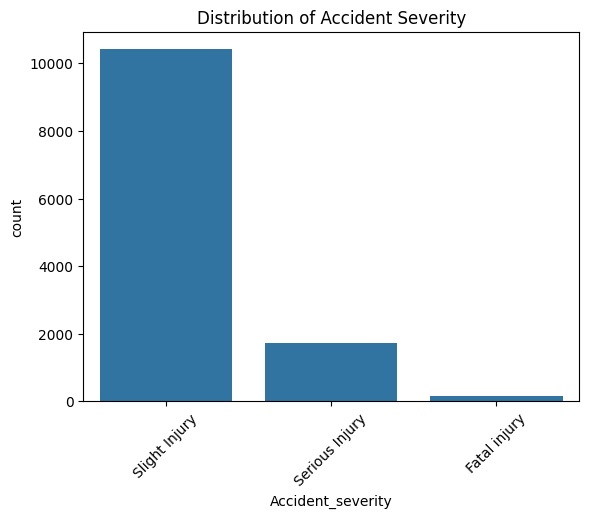

In [17]:
import seaborn as sns
import matplotlib.pyplot as ply

sns.countplot(data = df, x = "Accident_severity")
plt.title("Distribution of Accident Severity")
plt.xticks(rotation = 45)
plt.show()

Accidents by Weather Condition (Most accidents happen in normal weather)

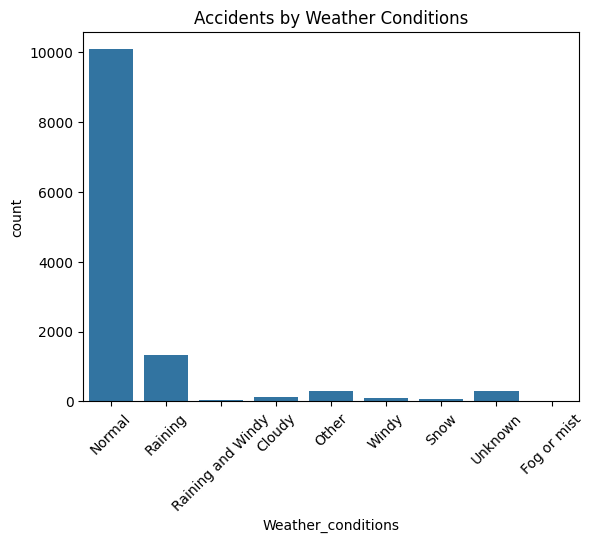

In [19]:
sns.countplot(data = df, x = "Weather_conditions")
plt.title("Accidents by Weather Conditions")
plt.xticks(rotation = 45)
plt.show()

Severity vs Light Condition (Dark conditions are more severe)

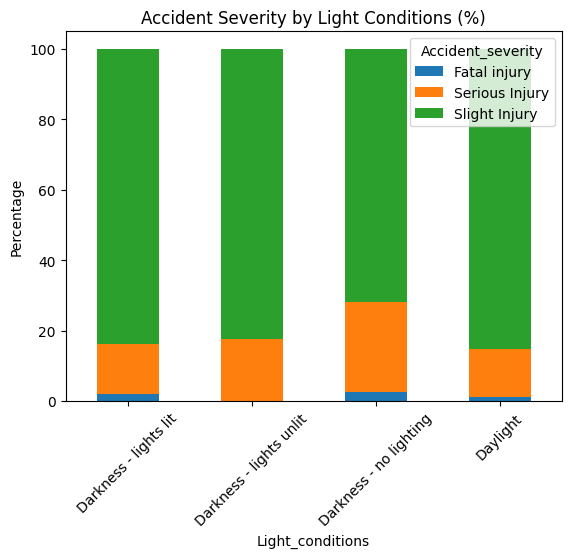

In [20]:
light_ct = pd.crosstab(df["Light_conditions"], df["Accident_severity"],
                       normalize = 'index') * 100
light_ct.plot(kind = "bar", stacked = True)
plt.title("Accident Severity by Light Conditions (%)")
plt.ylabel("Percentage")
plt.xticks(rotation = 45)
plt.show()

Severity vs Age Group (Young drivers have more severe accidents)

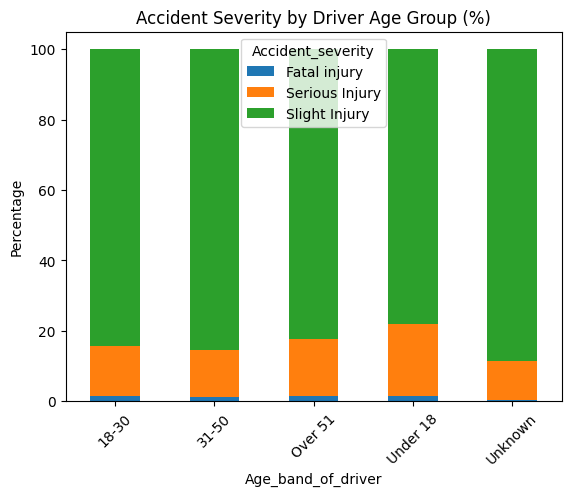

In [21]:
age_ct = pd.crosstab(df["Age_band_of_driver"], df["Accident_severity"],
                     normalize = 'index') * 100
age_ct.plot(kind = "bar", stacked = True)
plt.title("Accident Severity by Driver Age Group (%)")
plt.ylabel("Percentage")
ply.xticks(rotation = 45)
plt.show()

Severity vs Vehicle Type

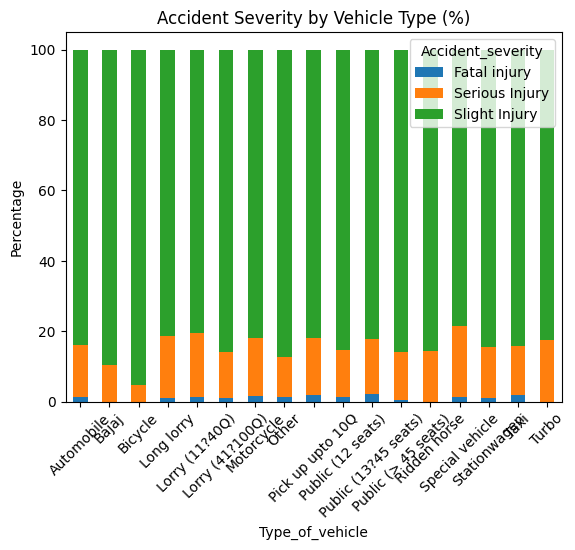

In [25]:
vehicle_ct = pd.crosstab(df["Type_of_vehicle"], df["Accident_severity"],
                         normalize = 'index') * 100
vehicle_ct.plot(kind = "bar", stacked = True)
plt.title("Accident Severity by Vehicle Type (%)")
plt.ylabel("Percentage")
plt.xticks(rotation = 45)
plt.show()

Which combination of factors makes accidents more severe?

In [26]:
combo = pd.crosstab([df["Light_conditions"], df["Weather_conditions"]],
                    df["Accident_severity"], normalize = 'index') * 100
combo

Accident_severity                           Fatal injury  Serious Injury  \
Light_conditions        Weather_conditions                                 
Darkness - lights lit   Cloudy                  0.000000        3.846154   
                        Fog or mist             0.000000        0.000000   
                        Normal                  2.363488       14.017930   
                        Other                   0.000000       11.904762   
                        Raining                 1.581028       14.624506   
                        Raining and Windy       0.000000        7.692308   
                        Snow                    0.000000       62.500000   
                        Unknown                 0.000000       22.058824   
                        Windy                   0.000000       18.181818   
Darkness - lights unlit Normal                  0.000000       16.666667   
                        Raining                 0.000000       22.222222   
                        Windy                   0.000000        0.000000   
Darkness - no lighting  Cloudy                  0.000000        0.000000   
                        Normal                  4.347826       32.173913   
                        Other                   0.000000        0.000000   
                        Raining                 0.000000       20.512821   
                        Snow                    0.000000        0.000000   
                        Unknown                 0.000000       33.333333   
                        Windy                   0.000000        0.000000   
Daylight                Cloudy                  0.000000        9.836066   
                        Fog or mist             0.000000       12.500000   
                        Normal                  0.964630       14.576635   
                        Other                   0.000000        7.738095   
                        Raining                 1.930502        9.523810   
                        Raining and Windy       0.000000        0.000000   
                        Snow                    0.000000        0.000000   
                        Unknown                 0.000000       15.094340   
                        Windy                   0.000000       17.021277   

Accident_severity                           Slight Injury  
Light_conditions        Weather_conditions                 
Darkness - lights lit   Cloudy                  96.153846  
                        Fog or mist            100.000000  
                        Normal                  83.618582  
                        Other                   88.095238  
                        Raining                 83.794466  
                        Raining and Windy       92.307692  
                        Snow                    37.500000  
                        Unknown                 77.941176  
                        Windy                   81.818182  
Darkness - lights unlit Normal                  83.333333  
                        Raining                 77.777778  
                        Windy                  100.000000  
Darkness - no lighting  Cloudy                 100.000000  
                        Normal                  63.478261  
                        Other                  100.000000  
                        Raining                 79.487179  
                        Snow                   100.000000  
                        Unknown                 66.666667  
                        Windy                  100.000000  
Daylight                Cloudy                  90.163934  
                        Fog or mist             87.500000  
                        Normal                  84.458735  
                        Other                   92.261905  
                        Raining                 88.545689  
                        Raining and Windy      100.000000  
                        Snow                   100.000000  
                        Unknown        